Matches shape: (71, 20)
Deliveries shape: (17103, 17)


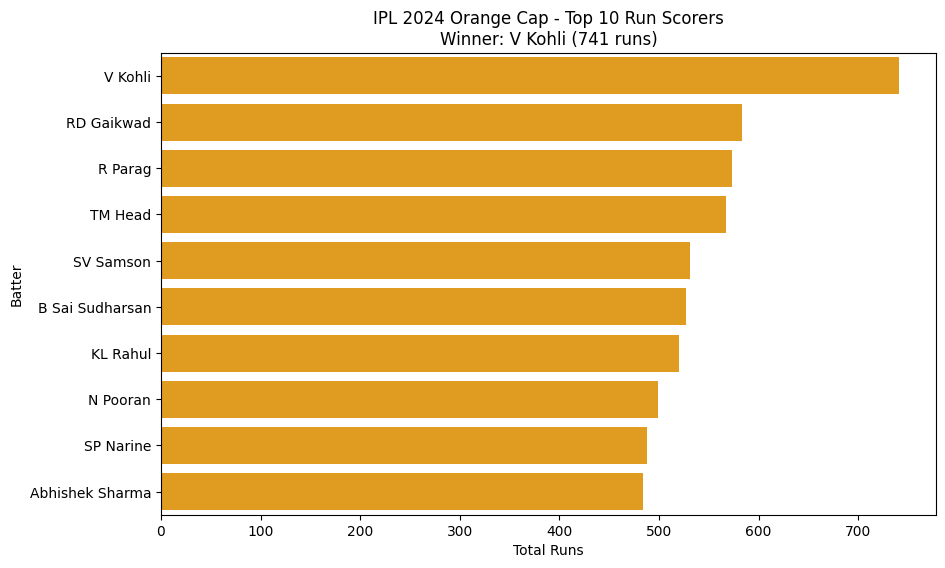

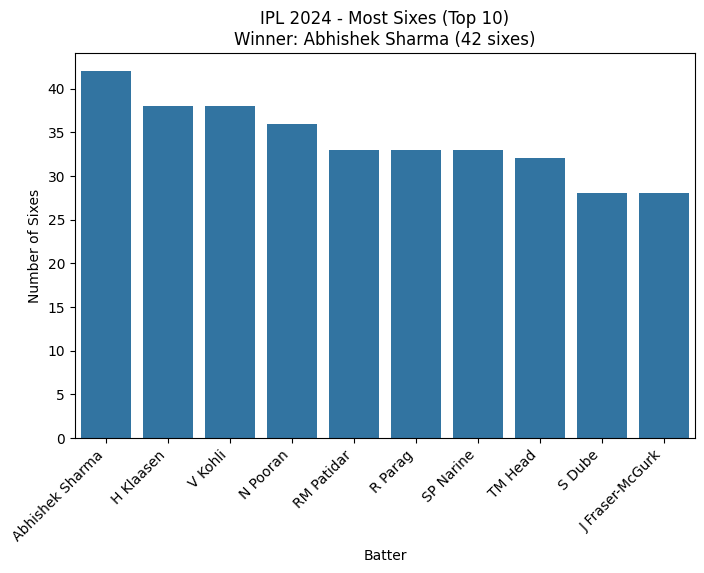

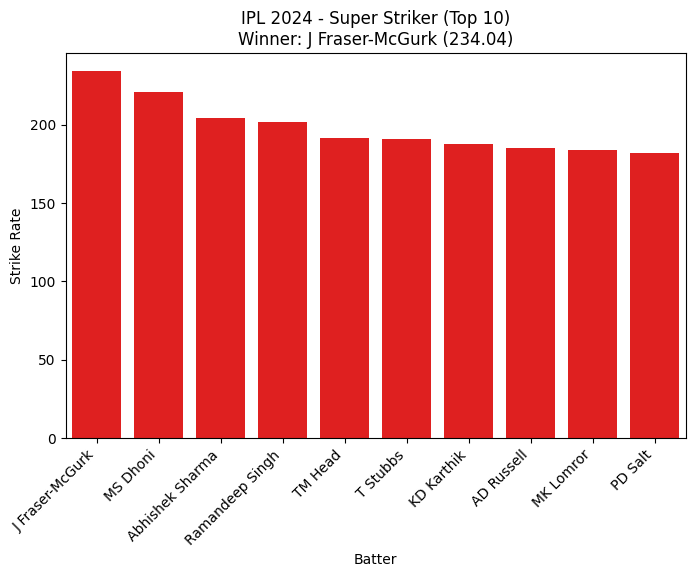

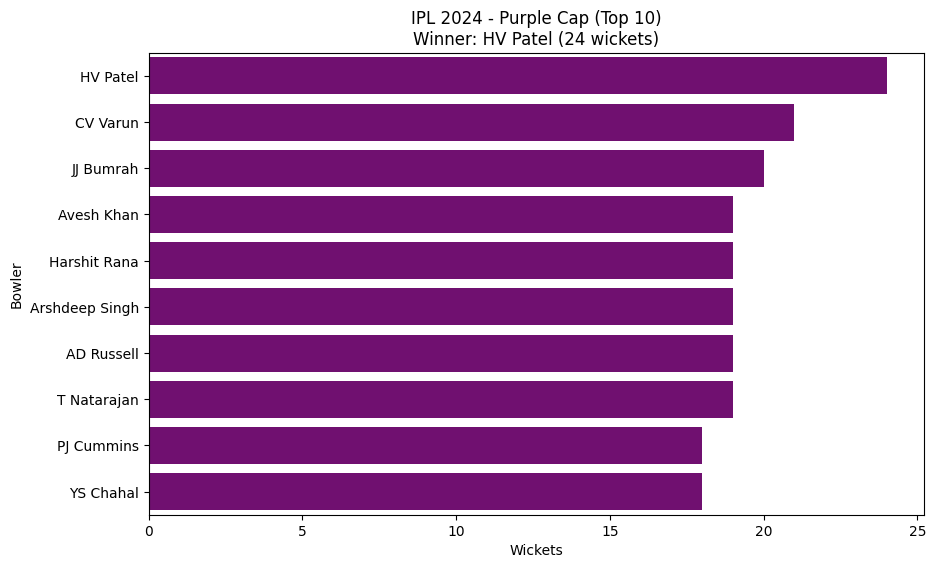

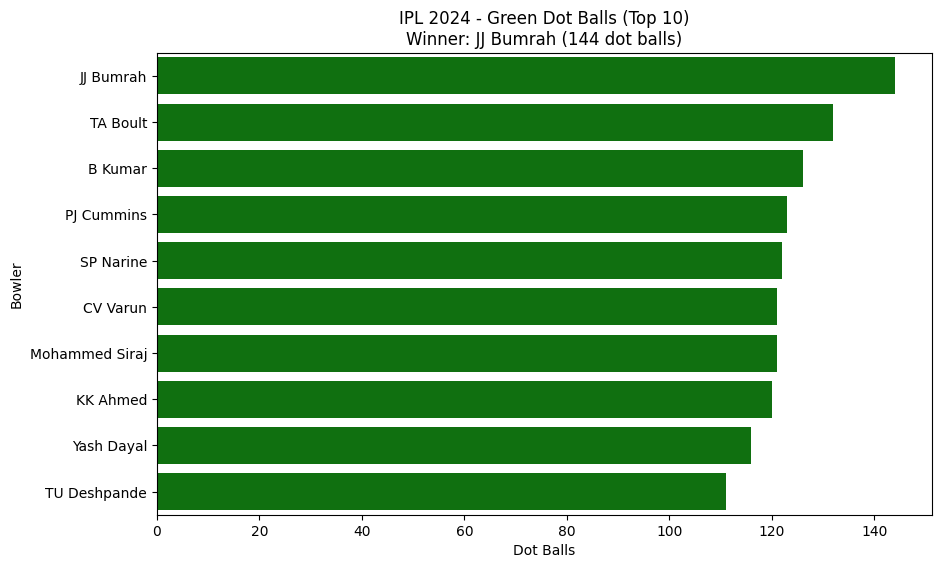

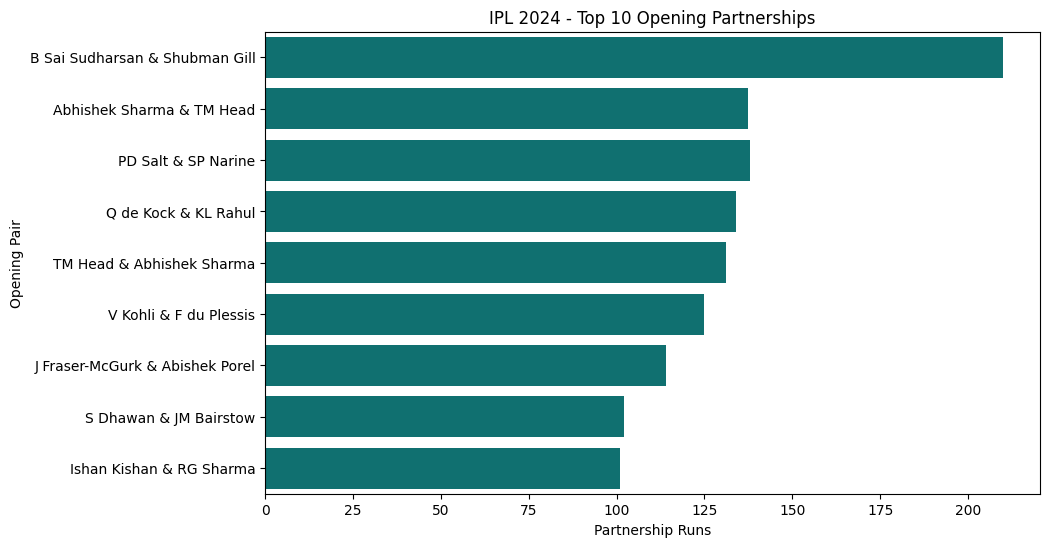

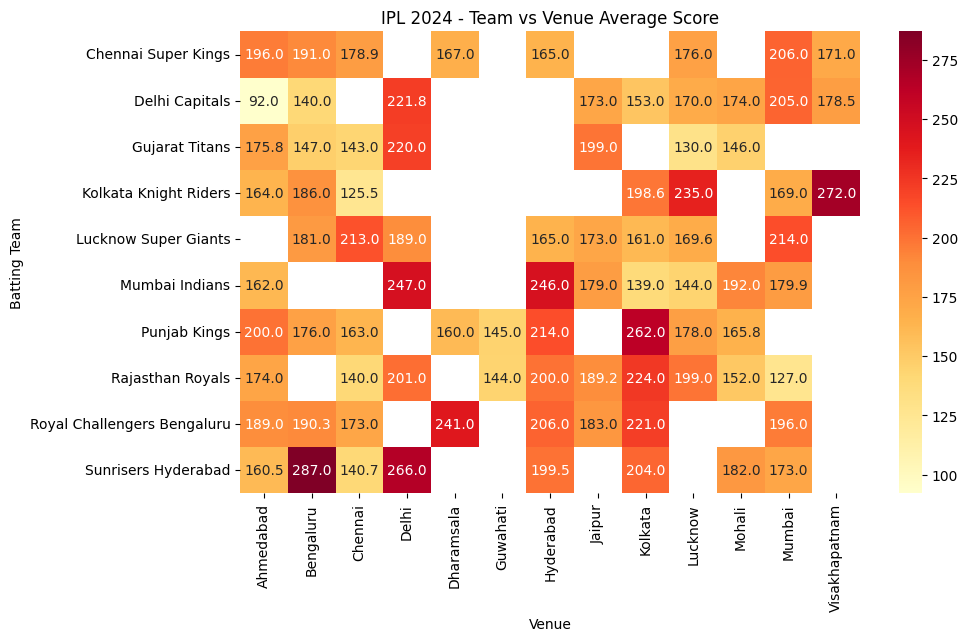

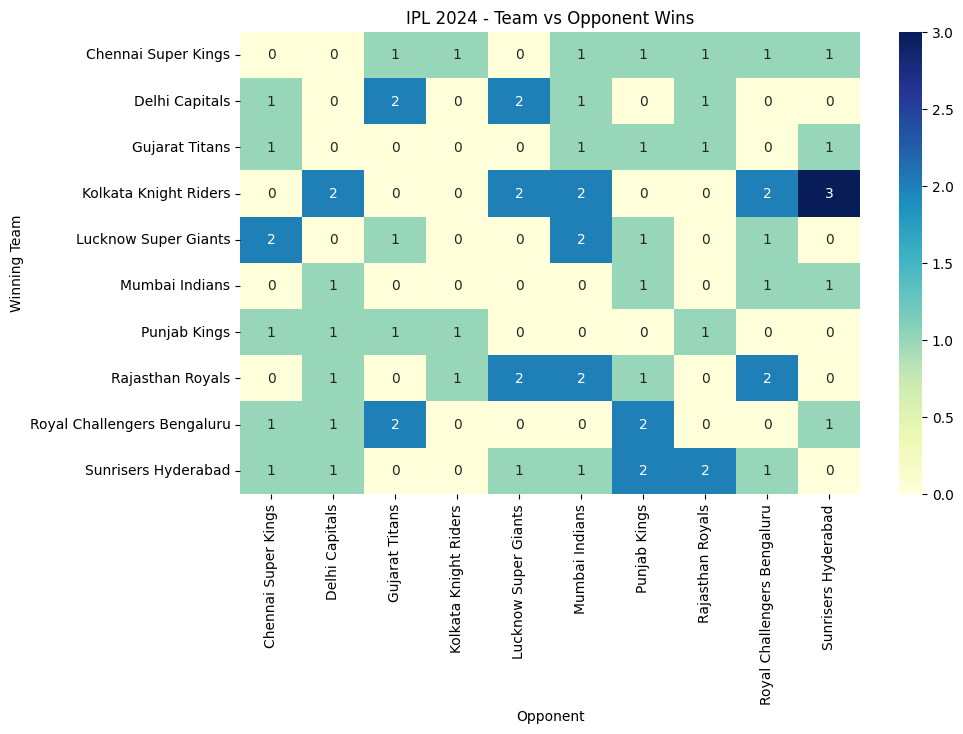

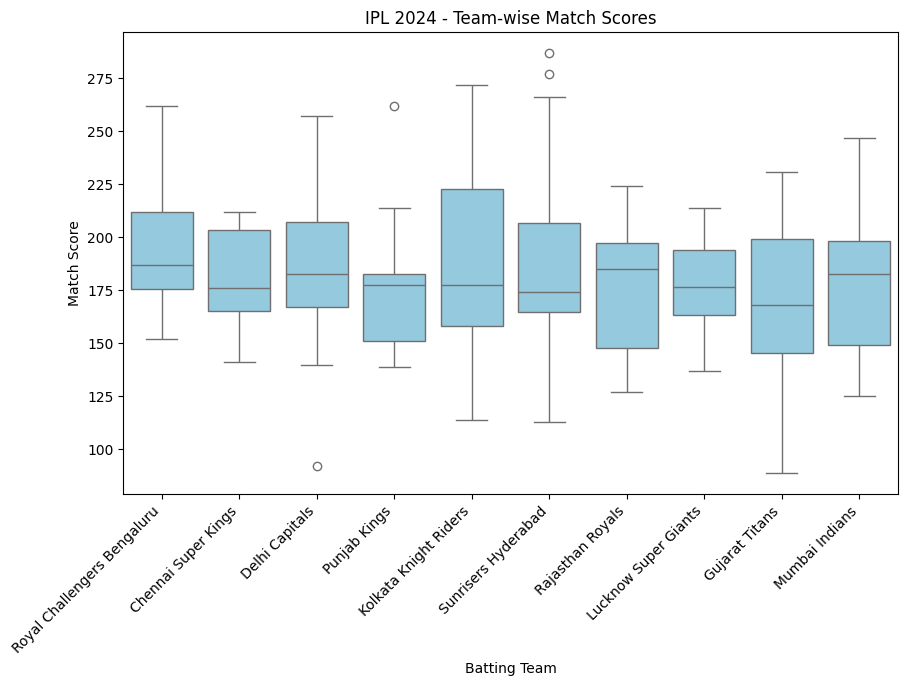

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

matches = pd.read_csv("matches_2024.csv")
deliveries = pd.read_csv("deliveries_2024.csv")

# check shape
print("Matches shape:", matches.shape)
print("Deliveries shape:", deliveries.shape)

# orange cap
orange_cap = deliveries.groupby("batter")["batsman_runs"].sum().reset_index()

orange_cap = orange_cap.sort_values(by="batsman_runs", ascending=False)

top10 = orange_cap.head(10)

winner = top10.iloc[0]

plt.figure(figsize=(10,6))
sns.barplot(data=top10, x="batsman_runs", y="batter",color='orange')

plt.title(f"IPL 2024 Orange Cap - Top 10 Run Scorers\nWinner: {winner['batter']} ({winner['batsman_runs']} runs)")
plt.xlabel("Total Runs")
plt.ylabel("Batter")

plt.show()

# Most Sixes
sixes = deliveries[deliveries["batsman_runs"] == 6]

most_sixes = sixes.groupby("batter").size().reset_index(name="sixes")
most_sixes = most_sixes.sort_values(by="sixes", ascending=False)

top10 = most_sixes.head(10)
winner = top10.iloc[0]

plt.figure(figsize=(8,5))
sns.barplot(data=top10, x="batter", y="sixes")

plt.title(f"IPL 2024 - Most Sixes (Top 10)\nWinner: {winner['batter']} ({winner['sixes']} sixes)")
plt.xlabel("Batter")
plt.ylabel("Number of Sixes")
plt.xticks(rotation=45, ha="right")
plt.show()

# Super Striker (minimum 60 balls faced)
balls_faced = deliveries[
    deliveries["extras_type"] != "wides"
].groupby("batter").size().reset_index(name="balls_faced")

runs_scored = deliveries.groupby("batter")["batsman_runs"].sum().reset_index(name="runs")

strike_rate = pd.merge(runs_scored, balls_faced, on="batter")

strike_rate = strike_rate[strike_rate["balls_faced"] >= 60]

strike_rate["strike_rate"] = (strike_rate["runs"] / strike_rate["balls_faced"]) * 100

strike_rate = strike_rate.sort_values(by="strike_rate", ascending=False)

top10 = strike_rate.head(10)
winner = top10.iloc[0]

plt.figure(figsize=(8,5))
sns.barplot(data=top10, x="batter", y="strike_rate", color="red")

plt.title(f"IPL 2024 - Super Striker (Top 10)\nWinner: {winner['batter']} ({winner['strike_rate']:.2f})")
plt.xlabel("Batter")
plt.ylabel("Strike Rate")
plt.xticks(rotation=45, ha="right")
plt.show()

wickets = deliveries[
    (deliveries["is_wicket"] == 1) &
    (~deliveries["dismissal_kind"].isin(["run out", "retired hurt", "obstructing the field"]))
]

#Purple cap
purple_cap = wickets.groupby("bowler").size().reset_index(name="wickets")
purple_cap = purple_cap.sort_values(by="wickets", ascending=False)

top10 = purple_cap.head(10)
winner = top10.iloc[0]

plt.figure(figsize=(10,6))
sns.barplot(data=top10, x="wickets", y="bowler", color="purple")

plt.title(f"IPL 2024 - Purple Cap (Top 10)\nWinner: {winner['bowler']} ({winner['wickets']} wickets)")
plt.xlabel("Wickets")
plt.ylabel("Bowler")
plt.show()

#Green dot balls
dot_balls = deliveries[deliveries["total_runs"] == 0]

green_dot = dot_balls.groupby("bowler").size().reset_index(name="dot_balls")
green_dot = green_dot.sort_values(by="dot_balls", ascending=False)

top10 = green_dot.head(10)
winner = top10.iloc[0]

plt.figure(figsize=(10,6))
sns.barplot(data=top10, x="dot_balls", y="bowler", color="green")

plt.title(f"IPL 2024 - Green Dot Balls (Top 10)\nWinner: {winner['bowler']} ({winner['dot_balls']} dot balls)")
plt.xlabel("Dot Balls")
plt.ylabel("Bowler")
plt.show()

#Top opening partnerships
partnerships = []

for (match_id, inning), group in deliveries.groupby(["match_id", "inning"]):
    group = group.sort_values(["over", "ball"])

    batting_team = group["batting_team"].iloc[0]
    batters = pd.unique(group[["batter", "non_striker"]].values.ravel())
    opener1, opener2 = batters[0], batters[1]

    first_wicket = group[group["is_wicket"] == 1]

    if not first_wicket.empty:
        wicket_index = first_wicket.index[0]
        opening_group = group.loc[:wicket_index-1]
    else:
        opening_group = group

    opening_runs = opening_group["total_runs"].sum()

    partnerships.append([match_id, inning, batting_team, opener1, opener2, opening_runs])

opening_df = pd.DataFrame(
    partnerships,
    columns=["match_id", "inning", "batting_team", "opener1", "opener2", "opening_runs"]
)

top10 = opening_df.sort_values(by="opening_runs", ascending=False).head(10)

top10["pair"] = top10["opener1"] + " & " + top10["opener2"]

plt.figure(figsize=(10,6))
sns.barplot(data=top10, x="opening_runs", y="pair", color="teal", errorbar=None)

plt.title("IPL 2024 - Top 10 Opening Partnerships")
plt.xlabel("Partnership Runs")
plt.ylabel("Opening Pair")
plt.show()

#Team vs Venue average score
innings_scores = deliveries.groupby(
    ["match_id", "inning", "batting_team"]
)["total_runs"].sum().reset_index(name="innings_score")

innings_scores = innings_scores.merge(
    matches[["id", "venue", "city"]],
    left_on="match_id",
    right_on="id",
    how="left"
)

innings_scores["venue_short"] = innings_scores["city"].fillna(innings_scores["venue"])

team_venue_avg = innings_scores.pivot_table(
    index="batting_team",
    columns="venue_short",
    values="innings_score",
    aggfunc="mean"
)

plt.figure(figsize=(10,6))
sns.heatmap(team_venue_avg, annot=True, cmap="YlOrRd", fmt=".1f")

plt.title("IPL 2024 - Team vs Venue Average Score")
plt.xlabel("Venue")
plt.ylabel("Batting Team")
plt.show()

#Team vs  Opponent Wins
heatmap_df = matches.copy()

heatmap_df["loser"] = heatmap_df.apply(
    lambda row: row["team2"] if row["winner"] == row["team1"] else row["team1"],
    axis=1
)

team_vs_opponent = heatmap_df.pivot_table(
    index="winner",
    columns="loser",
    aggfunc="size",
    fill_value=0
)

plt.figure(figsize=(10,6))
sns.heatmap(team_vs_opponent, annot=True, cmap="YlGnBu", fmt="d")

plt.title("IPL 2024 - Team vs Opponent Wins")
plt.xlabel("Opponent")
plt.ylabel("Winning Team")
plt.show()

#Team wise match score
team_scores = deliveries.groupby(
    ["match_id", "inning", "batting_team"]
)["total_runs"].sum().reset_index(name="team_score")

plt.figure(figsize=(10,6))
sns.boxplot(data=team_scores, x="batting_team", y="team_score", color="skyblue")

plt.title("IPL 2024 - Team-wise Match Scores")
plt.xlabel("Batting Team")
plt.ylabel("Match Score")
plt.xticks(rotation=45, ha="right")
plt.show()